# Shiladitya **2348556**

`QuantumCircuit` is used to create quantum circuits, while transpile prepares a circuit for execution on a specific quantum backend.

`plot_histogram` function from `qiskit.visualization` is used to visualize the results of quantum measurements as a histogram.

`AerSimulator` class from the `qiskit_aer` module is a simulator that can run quantum circuits in a way that mimics how they would behave on a real quantum computer.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.primitives import Sampler
from qiskit.quantum_info import Statevector
import warnings
warnings.filterwarnings('ignore')

## Q1.

### define and draw the circuit

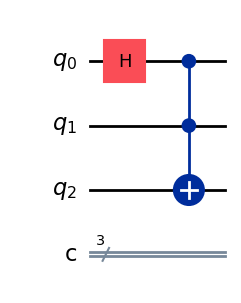

In [2]:
circuit_1 = QuantumCircuit(3, 3)
circuit_1.h(0)
circuit_1.ccx(0,1,2)
display(circuit_1.draw(output='mpl'))

In [4]:
Statevector.from_instruction(circuit_1).draw('latex')

<IPython.core.display.Latex object>

### measurement

In [298]:
circuit_1.measure([0,1,2], [0,1,2]);

In [299]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit_1, simulator)

In [300]:
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit_1)

### actual counts (varies)

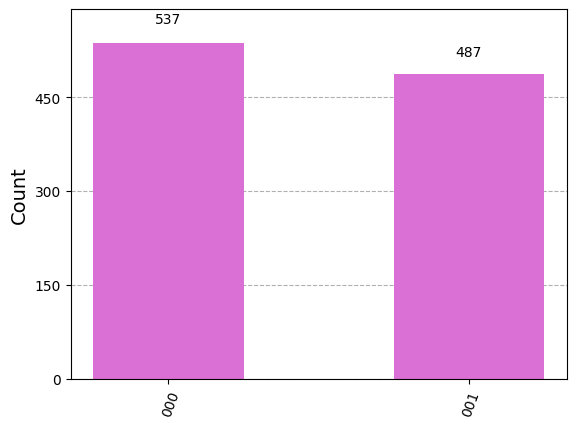

In [301]:
plot_histogram(counts, color='orchid')

### probability of each

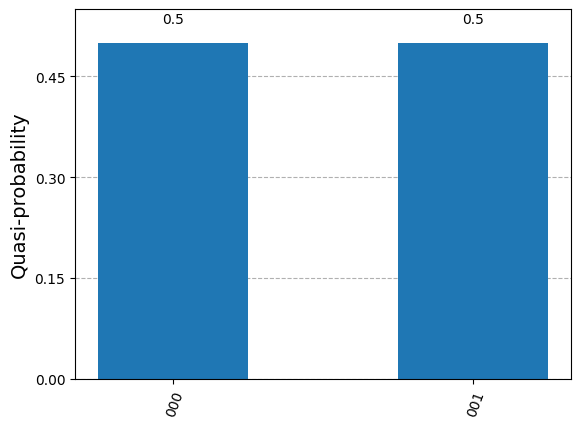

In [302]:
results = Sampler().run(circuit_1).result()
proba = results.quasi_dists[0].binary_probabilities()
plot_histogram(proba)

## Q2.

### define and draw the circuit

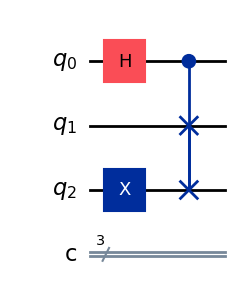

In [6]:
circuit_2 = QuantumCircuit(3,3)
circuit_2.h(0)
circuit_2.x(2)
circuit_2.cswap(0,1,2)
display(circuit_2.draw(output='mpl'))

In [7]:
Statevector.from_instruction(circuit_2).draw('latex')

<IPython.core.display.Latex object>

### measurement

In [304]:
circuit_2.measure([0,1,2], [0,1,2]);

In [305]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit_2, simulator)

In [306]:
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit_2)

### actual counts

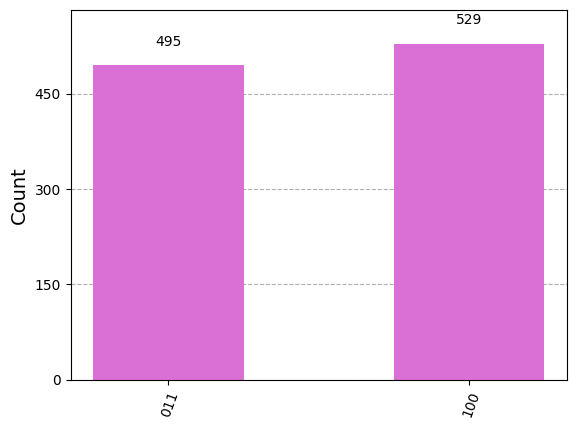

In [307]:
plot_histogram(counts, color='orchid')

### probabilities

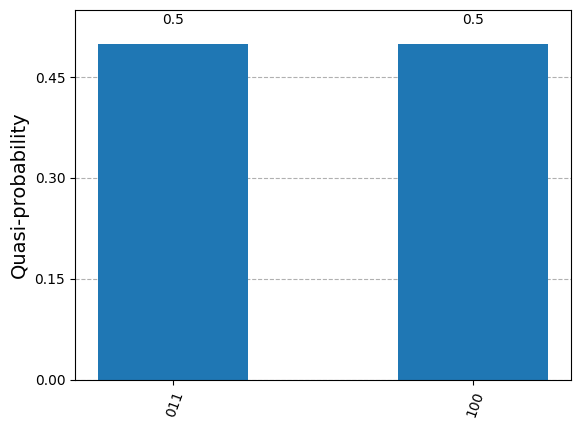

In [308]:
results = Sampler().run(circuit_2).result()
proba = results.quasi_dists[0].binary_probabilities()
plot_histogram(proba)

## Q3.

### (a)

### define and draw the circuit

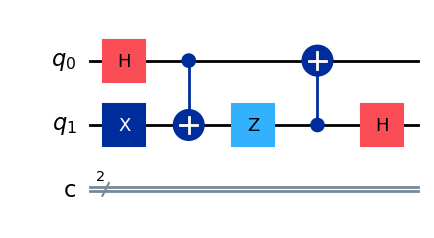

In [8]:
circuit_3 = QuantumCircuit(2, 2)
circuit_3.x(1)
circuit_3.h(0)
circuit_3.cx(0,1)
circuit_3.z(1)
circuit_3.cx(1,0)
circuit_3.h(1)
display(circuit_3.draw(output='mpl'))

In [9]:
Statevector.from_instruction(circuit_3).draw('latex')

<IPython.core.display.Latex object>

### measurement

In [310]:
circuit_3.measure([0,1],[0,1]);

In [311]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit_3, simulator)

In [312]:
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(circuit_3)

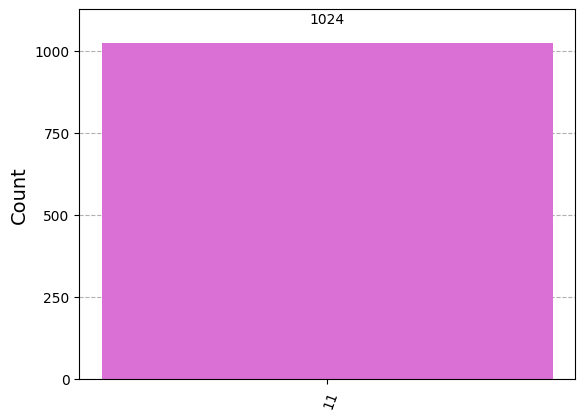

In [313]:
plot_histogram(counts, color='orchid')

### probability of outcome

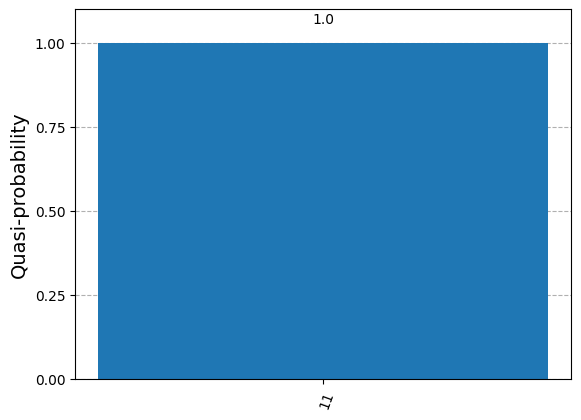

In [314]:
results = Sampler().run(circuit_3).result()
proba = results.quasi_dists[0].binary_probabilities()
plot_histogram(proba)

### (b)

### blueprint of the idea

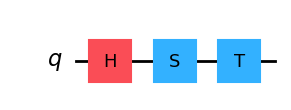

In [10]:
circuit_check = QuantumCircuit(1)
circuit_check.h(0)
circuit_check.s(0)
circuit_check.t(0)
display(circuit_check.draw(output='mpl'))

### Now see what happens when we try out different combinations of these unitary gates ...

In [12]:
# Circuit 1: H -> S -> T
circuit1 = QuantumCircuit(1)
circuit1.h(0)
circuit1.s(0)
circuit1.t(0)

# Circuit 2: H -> T -> S
circuit2 = QuantumCircuit(1)
circuit2.h(0)
circuit2.t(0)
circuit2.s(0)

# Circuit 3: S -> H -> T
circuit3 = QuantumCircuit(1)
circuit3.s(0)
circuit3.h(0)
circuit3.t(0)

# Circuit 4: T -> H -> S
circuit4 = QuantumCircuit(1)
circuit4.t(0)
circuit4.h(0)
circuit4.s(0)

# Circuit 5: S -> T -> H
circuit5 = QuantumCircuit(1)
circuit5.s(0)
circuit5.t(0)
circuit5.h(0)

# Circuit 6: T -> S -> H
circuit6 = QuantumCircuit(1)
circuit6.t(0)
circuit6.s(0)
circuit6.h(0);

In [324]:
Statevector.from_instruction(circuit1).draw('latex')

<IPython.core.display.Latex object>

In [13]:
Statevector.from_instruction(circuit6).draw('latex')

<IPython.core.display.Latex object>

In [14]:
Statevector.from_instruction(circuit2).draw('latex')

<IPython.core.display.Latex object>

In [15]:
Statevector.from_instruction(circuit4).draw('latex')

<IPython.core.display.Latex object>

In [16]:
Statevector.from_instruction(circuit3).draw('latex')

<IPython.core.display.Latex object>

In [17]:
Statevector.from_instruction(circuit5).draw('latex')

<IPython.core.display.Latex object>

We see that the results are different.